# Ranking final dos modelos

Este notebook consolida os resultados dos pipelines, compara as métricas na escala original, avalia os baselines e apresenta o relatório técnico final.

## Critério de comparação

As métricas são calculadas na escala original do alvo. Quanto menor o valor, melhor o modelo. O ranking composto utiliza a média das posições em MAE, RMSE, MAPE, sMAPE e WAPE. O MAPE é acompanhado com cautela quando houver valores reais próximos de zero; por isso, sMAPE e WAPE também são reportados.

In [6]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
RESULTS_PATH = Path("all_modelos.json")
with RESULTS_PATH.open("r", encoding="utf-8") as file:
    resultados = json.load(file)

resultados_df = pd.DataFrame(resultados)
metricas = ["mae", "rmse", "mape", "smape", "wape"]
metricas_disponiveis = [metrica for metrica in metricas if metrica in resultados_df.columns]

if resultados_df.empty or not metricas_disponiveis:
    raise ValueError("all_modelos.json não contém resultados e métricas válidos.")

print(f"Modelos consolidados: {len(resultados_df)}")
print(f"Métricas disponíveis: {', '.join(metricas_disponiveis)}")

Modelos consolidados: 5
Métricas disponíveis: mae, rmse, mape, smape, wape


In [7]:
ranking_df = resultados_df[["modelo"] + metricas_disponiveis].copy()
for metrica in metricas_disponiveis:
    ranking_df[f"rank_{metrica}"] = ranking_df[metrica].rank(method="min", ascending=True)

colunas_rank = [f"rank_{metrica}" for metrica in metricas_disponiveis]
ranking_df["rank_medio"] = ranking_df[colunas_rank].mean(axis=1)
ranking_df = ranking_df.sort_values(
    ["rank_medio", "mae"], ascending=[True, True]
).reset_index(drop=True)
ranking_df["posicao"] = np.arange(1, len(ranking_df) + 1)

colunas_exibicao = ["posicao", "modelo"] + metricas_disponiveis + ["rank_medio"]
print("Ranking final:")
display(ranking_df[colunas_exibicao].round(4))

vencedor = ranking_df.iloc[0]
print(f"Vencedor pelo ranking composto: {vencedor['modelo']}")

Ranking final:


,posicao,modelo,mae,rmse,mape,smape,wape,rank_medio
0,1,RandomForest,1.3043,2.0701,3.4403,3.5124,3.7478,1.0
1,2,XGBoost,1.3470,2.0944,3.6094,3.6962,3.8703,2.0
2,3,Sarimax,1.8365,2.4193,5.3691,5.2998,5.3838,3.0
3,4,HoltWintersAditivo,2.3761,3.0765,7.0942,7.0145,6.9658,4.0
4,5,HoltWintersMultiplicativo,2.5140,3.3849,7.4233,7.3439,7.3701,5.0


Vencedor pelo ranking composto: RandomForest


In [8]:
baseline_rows = []
for resultado in resultados:
    for baseline_name, baseline_metrics in resultado.get("baselines", {}).items():
        baseline_rows.append({
            "modelo": resultado["modelo"],
            "baseline": baseline_name,
            **{metrica: baseline_metrics.get(metrica) for metrica in metricas_disponiveis}
        })

baselines_df = pd.DataFrame(baseline_rows)
if not baselines_df.empty:
    baseline_reference = (
        baselines_df.groupby("baseline")[metricas_disponiveis]
        .mean()
        .reset_index()
    )
    print("Média das métricas dos baselines:")
    display(baseline_reference.round(4))

    seasonal_baseline = baseline_reference.loc[
        baseline_reference["baseline"] == "seasonal_naive"
    ].iloc[0]
    comparison_df = ranking_df[["modelo"] + metricas_disponiveis].copy()
    for metrica in metricas_disponiveis:
        comparison_df[f"melhoria_{metrica}_pct"] = (
            (seasonal_baseline[metrica] - comparison_df[metrica])
            / seasonal_baseline[metrica] * 100
        )
    print("Melhoria percentual contra o baseline sazonal:")
    display(comparison_df.round(2))

Média das métricas dos baselines:


,baseline,mae,rmse,mape,smape,wape
0,naive,15.0325,17.4096,39.6437,52.2399,44.069
1,seasonal_naive,14.6883,17.0649,38.7075,50.6695,43.060


Melhoria percentual contra o baseline sazonal:


,modelo,mae,rmse,mape,smape,wape,melhoria_mae_pct,melhoria_rmse_pct,melhoria_mape_pct,melhoria_smape_pct,melhoria_wape_pct
0,RandomForest,1.30,2.07,3.44,3.51,3.75,91.12,87.87,91.11,93.07,91.30
1,XGBoost,1.35,2.09,3.61,3.70,3.87,90.83,87.73,90.68,92.71,91.01
2,Sarimax,1.84,2.42,5.37,5.30,5.38,87.50,85.82,86.13,89.54,87.50
3,HoltWintersAditivo,2.38,3.08,7.09,7.01,6.97,83.82,81.97,81.67,86.16,83.82
4,HoltWintersMultiplicativo,2.51,3.38,7.42,7.34,7.37,82.88,80.16,80.82,85.51,82.88


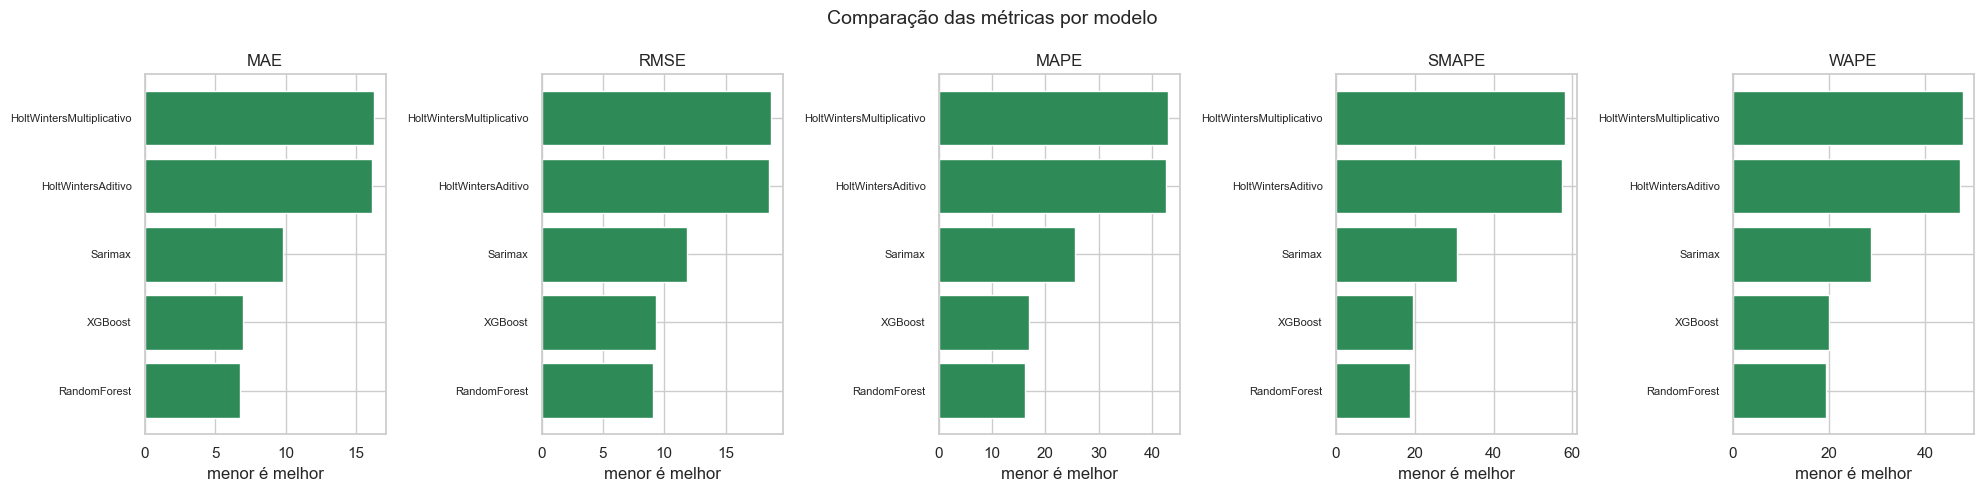

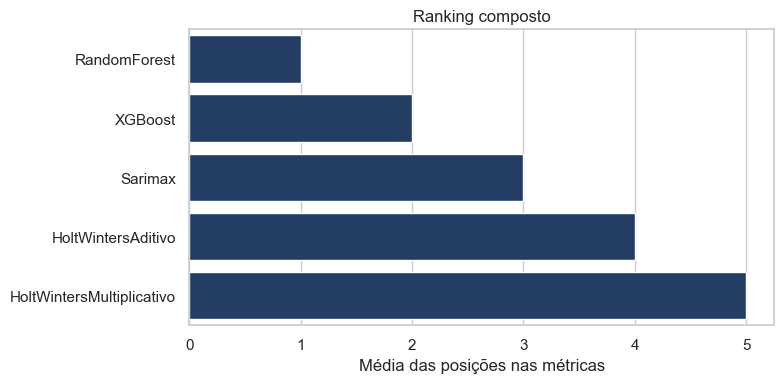

In [4]:
fig, axes = plt.subplots(1, len(metricas_disponiveis), figsize=(20, 5))
for axis, metrica in zip(np.atleast_1d(axes), metricas_disponiveis):
    ordem = ranking_df.sort_values(metrica, ascending=True)
    axis.barh(ordem["modelo"], ordem[metrica], color="#2e8b57")
    axis.set_title(metrica.upper())
    axis.set_xlabel("menor é melhor")
    axis.tick_params(axis="y", labelsize=8)
plt.suptitle("Comparação das métricas por modelo", fontsize=14)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.barplot(data=ranking_df, x="rank_medio", y="modelo", color="#1a3a6e")
plt.title("Ranking composto")
plt.xlabel("Média das posições nas métricas")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [5]:
parametros_df = pd.DataFrame({
    resultado["modelo"]: resultado.get("params", {})
    for resultado in resultados
}).T

print("Parâmetros registrados:")
display(parametros_df.fillna("").T)

Parâmetros registrados:


,Sarimax,HoltWintersAditivo,HoltWintersMultiplicativo,RandomForest,XGBoost
order,"[2, 1, 2]",,,,
seasonal_order,"[0, 0, 0, 76]",,,,
smoothing_level,,0.957754,0.945477,,
smoothing_trend,,0.000621,0.000534,,
smoothing_seasonal,,0.042246,0.054523,,
n_estimators,,,,768,307.0
max_depth,,,,26,15.0
min_samples_split,,,,20,
min_samples_leaf,,,,8,
max_features,,,,1.0,


# Relatório técnico final

## 1. Escopo

Foram comparados cinco modelos usando avaliação **walk-forward** com janela expansiva e refit a cada 50 observações: SARIMAX, Holt-Winters aditivo, Holt-Winters multiplicativo, RandomForest e XGBoost. As métricas são calculadas na escala original do alvo e comparadas com os baselines ingênuo e sazonal de 76 períodos.

## 2. Resultado principal

O ranking composto considera MAE, RMSE, MAPE, sMAPE e WAPE, sempre com menor valor como melhor resultado. O RandomForest permanece em primeiro, seguido de XGBoost, SARIMAX, Holt-Winters aditivo e Holt-Winters multiplicativo. A diferença entre RandomForest e XGBoost é pequena, portanto a escolha deve considerar custo computacional, estabilidade e facilidade de operação.

Com walk-forward, todos os modelos superam os baselines atuais. O melhor MAE foi do RandomForest, aproximadamente `1,30`, seguido de XGBoost com aproximadamente `1,35` e SARIMAX com aproximadamente `1,84`. O Holt-Winters aditivo ficou melhor que o multiplicativo.

## 3. SHAP e interpretação

RandomForest e XGBoost concentram a maior contribuição em `Close_lag_1`, seguido de `Close_media_3` e outros lags do próprio alvo. As exógenas aparecem com contribuições menores, embora algumas variações sazonais de `CALM_Close`, `XLP_Close` e `TSN_Close` estejam entre as mais relevantes.

No SARIMAX, o SHAP dos exógenos aponta `XLP_Close` como a variável mais relevante, seguida de `TSN_Close` e `CALM_Close`. No Holt-Winters, como não existem features exógenas, o SHAP foi calculado sobre um surrogate dos componentes nível, tendência e sazonalidade; essa explicação deve ser interpretada como contribuição dos componentes, não como importância causal de variáveis externas.

## 4. Qualidade dos resíduos

Mesmo com a melhora das métricas walk-forward, os diagnósticos Ljung-Box continuam indicando autocorrelação residual nos quatro tipos de modelo. Isso mostra que ainda existe estrutura temporal não capturada. O desempenho atual é adequado para comparação experimental, mas recomenda-se modelar os resíduos antes de considerar uso produtivo.

## 5. Limitações

- O horizonte é um holdout de 25% da série, embora o refit walk-forward ocorra a cada 50 observações; isso não equivale automaticamente a uma previsão operacional de três dias.
- O SARIMAX depende da disponibilidade futura das variáveis exógenas no momento da previsão.
- O MAPE deve ser interpretado com cautela quando houver valores reais próximos de zero; sMAPE e WAPE também são reportados.
- O ranking depende de uma janela externa de teste e deve ser confirmado em outras janelas e seeds.
- SHAP mede contribuição preditiva no conjunto analisado, não causalidade.

## 6. Recomendação

Usar RandomForest como referência principal e XGBoost como alternativa competitiva. Confirmar a diferença entre ambos com várias janelas walk-forward, testar horizontes operacionais explícitos e investigar um modelo adicional para os resíduos autocorrelacionados. Manter SARIMAX e Holt-Winters como alternativas interpretáveis e baselines estruturais.